# AMIGOS (all 40 participants): Self-supervised ECG emotion recognition (Sarkar & Etemad, 2020)
Same pipeline as `amigos_ssl_ecg.ipynb` (15 participants), run on the Kaggle copy with all 40 participants. The files for the shared participants are identical, so the two runs are directly comparable (section 8).

Re-implementation of *Self-supervised ECG Representation Learning for Emotion Recognition* (IEEE TAC 2020).

**Two stages**
1. **Pretext (no labels):** a multi-task CNN learns to recognise 6 transformations of 10-s ECG windows (noise, scaling, negation, temporal inversion, permutation, time-warping) plus the original.
2. **Emotion:** the conv layers are frozen and a small dense network is trained on top to predict high/low **arousal** and **valence**.

**Three evaluation schemes** (same idea as the K-EmoCon notebook)
| Scheme | What it means |
|---|---|
| `paper_10fold` | Paper protocol: all windows shuffled, 10-fold. Windows from the same video are in train and test. |
| `trial_10fold` | Subject-dependent but honest: every window of a video stays on one side of the split. |
| `loso` | Leave-one-subject-out: tested on a person the model never saw. |

**Differences from the paper (unavoidable):** P09's ECG is missing for 11 of its 16 short videos, so those trials are skipped; preprocessed 128 Hz ECG upsampled to 256 Hz; pretext trained on AMIGOS only (the paper's best numbers also used DREAMER, WESAD and SWELL); PyTorch instead of TensorFlow.

Run top to bottom. Use the **`torch`** conda environment as the kernel (it has PyTorch with CUDA).

In [1]:
# ===== EDIT THIS =====
ROOT = r"C:\Users\User\Desktop\VS_CODE\Sahi\AMIGOS PreProcessed"
# any folder that contains the Data_Preprocessed_Pxx folders (searched recursively)
RESULTS_15 = "amigos_ssl_ecg_results.csv"   # results of the 15-participant notebook, for the comparison in section 8
# ====================

# ---- data ----
ECG_CHANNEL = 14           # joined_data columns: 0-13 EEG, 14 = ECG right, 15 = ECG left, 16 = GSR
FS_IN, FS = 128, 256       # preprocessed AMIGOS is 128 Hz; the paper's network expects 256 Hz (10 s = 2560 samples)
WIN_SEC = 10               # non-overlapping windows (paper)
USE_LONG_VIDEOS = False    # paper: the 16 short videos. True adds the 4 long videos (~3.7x more windows, much slower)
HIGHPASS_HZ = 0.8          # baseline-wander removal (paper)
THRESHOLD = "global_mean"  # "global_mean" (paper: mean rating) | "subject_mean" | "midpoint" (rating > 5)

# ---- self-supervised transformations: paper's best (SNR, scale, perm segments, warp segments, stretch) ----
SNR_DB, SCALE, N_PERM, N_WARP, STRETCH = 15, 0.9, 20, 9, 1.05

# ---- training (paper: Adam lr 1e-3, batch 128, 100 pretext epochs, 250 emotion epochs) ----
LR, BATCH = 1e-3, 128
PRETEXT_EPOCHS, EMOTION_EPOCHS = 100, 250
PRETEXT_PER_FOLD = False   # False: pretext CNN trained once on all windows (uses no labels; ~20 min on an RTX 5060)
                           # True: retrained on each fold's training windows only (strict; 60 folds, ~20 h)
SUPERVISED_SCHEMES = []    # paper's fully-supervised CNN baseline, e.g. ["paper_10fold"] (~8 min per fold per task)
SCHEMES = ["paper_10fold", "trial_10fold", "loso"]
SEED = 42

In [2]:
import re, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, scipy.io as sio
from scipy import signal
import torch, torch.nn as nn, torch.nn.functional as F
from sklearn.model_selection import KFold, GroupKFold, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
np.random.seed(SEED); torch.manual_seed(SEED)
WIN = FS * WIN_SEC
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

device: cuda NVIDIA GeForce RTX 5060 Laptop GPU


## 1) Load ECG + self-assessed arousal/valence

In [3]:
def load_amigos(root, use_long=USE_LONG_VIDEOS, ch=ECG_CHANNEL):
    files = sorted(Path(root).rglob("Data_Preprocessed_P*.mat"))
    if not files:
        raise FileNotFoundError(f"No Data_Preprocessed_P*.mat under {root}")
    trials, skipped = [], []
    for fp in files:
        pid = int(re.search(r"P(\d+)", fp.stem).group(1))
        m = sio.loadmat(fp, squeeze_me=True)
        for i, (x, lab, vid) in enumerate(zip(m["joined_data"], m["labels_selfassessment"], m["VideoIDs"])):
            if i >= 16 and not use_long:      # trials 17-20 are the long videos
                continue
            x = np.asarray(x, float)
            lab = np.atleast_1d(np.asarray(lab, float))
            # some participants have no long-video data (empty trials)
            if x.ndim != 2 or len(x) < FS_IN * WIN_SEC or lab.size < 2 or np.isnan(lab[:2]).any():
                skipped.append((pid, i + 1, "no data/label"))
                continue
            # missing or flat ECG (e.g. P09) would become constant windows after nan_to_num
            if np.isnan(x[:, ch]).any() or np.nanstd(x[:, ch]) == 0:
                skipped.append((pid, i + 1, "ECG missing"))
                continue
            trials.append(dict(pid=pid, trial=i + 1, video=str(vid), ecg=x[:, ch],
                               arousal=lab[0], valence=lab[1]))   # labels: [arousal, valence, dominance, ...]
    return trials, skipped


trials, skipped = load_amigos(ROOT)
print(f"{len(trials)} trials from {len({t['pid'] for t in trials})} participants:",
      sorted({t['pid'] for t in trials}))
print(f"skipped {len(skipped)} trials:", skipped)

629 trials from 40 participants: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
skipped 11 trials: [(9, 1, 'ECG missing'), (9, 2, 'ECG missing'), (9, 3, 'ECG missing'), (9, 6, 'ECG missing'), (9, 7, 'ECG missing'), (9, 9, 'ECG missing'), (9, 11, 'ECG missing'), (9, 12, 'ECG missing'), (9, 13, 'ECG missing'), (9, 15, 'ECG missing'), (9, 16, 'ECG missing')]


## 2) Pre-processing (paper §4.2)
High-pass 0.8 Hz → upsample 128 → 256 Hz → per-participant z-score → 10-s non-overlapping windows. Every window inherits its video's rating.

In [4]:
SOS_HP = signal.butter(4, HIGHPASS_HZ, btype="highpass", fs=FS_IN, output="sos")


def preprocess_trial(ecg):
    y = signal.sosfiltfilt(SOS_HP, np.nan_to_num(ecg))
    return signal.resample_poly(y, FS, FS_IN) if FS != FS_IN else y


def build_windows(trials):
    X, meta = [], []
    for pid in sorted({t["pid"] for t in trials}):
        sig = [(t, preprocess_trial(t["ecg"])) for t in trials if t["pid"] == pid]
        allv = np.concatenate([s for _, s in sig])
        mu, sd = allv.mean(), allv.std()              # user-specific z-score (paper)
        for t, s in sig:
            s = (s - mu) / sd
            for w in range(len(s) // WIN):
                X.append(s[w * WIN:(w + 1) * WIN])
                meta.append(dict(pid=pid, trial=t["trial"], video=t["video"], window=w,
                                 arousal=t["arousal"], valence=t["valence"]))
    return np.stack(X).astype(np.float32), pd.DataFrame(meta)


def add_labels(meta, how=THRESHOLD):
    meta = meta.copy()
    for t in ["arousal", "valence"]:
        if how == "global_mean":
            thr = meta[t].mean()
        elif how == "subject_mean":
            thr = meta.groupby("pid")[t].transform("mean")
        else:
            thr = 5.0
        meta[f"{t}_bin"] = (meta[t] > thr).astype(int)
    return meta


X, meta = build_windows(trials)
meta = add_labels(meta)
print("windows:", X.shape, "| per participant:", meta.groupby("pid").size().to_dict())
for t in ["arousal", "valence"]:
    print(f"{t:8s} high-class share: {meta[f'{t}_bin'].mean():.3f}")

windows: (5499, 2560) | per participant: {1: 140, 2: 140, 3: 140, 4: 140, 5: 140, 6: 140, 7: 140, 8: 140, 9: 39, 10: 140, 11: 140, 12: 140, 13: 140, 14: 140, 15: 140, 16: 140, 17: 140, 18: 140, 19: 140, 20: 140, 21: 140, 22: 140, 23: 140, 24: 140, 25: 140, 26: 140, 27: 140, 28: 140, 29: 140, 30: 140, 31: 140, 32: 140, 33: 140, 34: 140, 35: 140, 36: 140, 37: 140, 38: 140, 39: 140, 40: 140}
arousal  high-class share: 0.520
valence  high-class share: 0.447


## 3) The six signal transformations (paper §3.1)

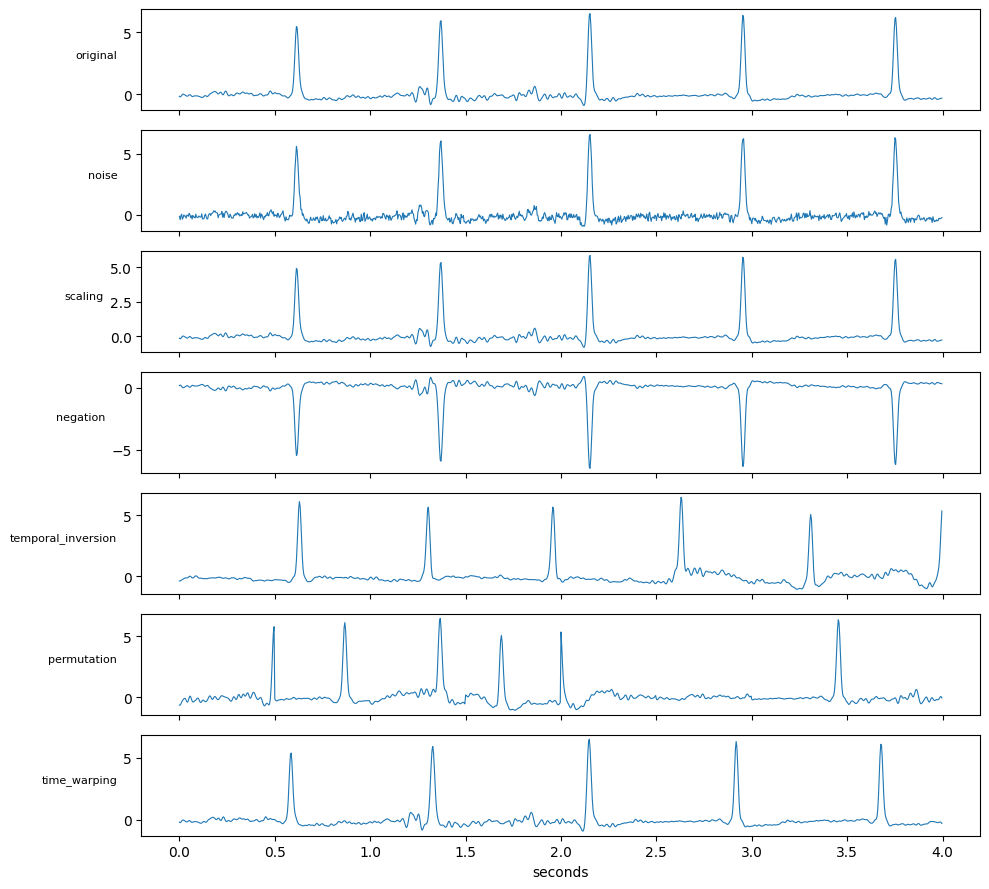

In [5]:
def add_noise(x, rng):
    p_noise = np.mean(x ** 2) / 10 ** (SNR_DB / 10)
    return x + rng.normal(0, np.sqrt(p_noise), x.shape)


def scale(x, rng):
    return SCALE * x


def negate(x, rng):
    return -x


def invert_time(x, rng):
    return x[::-1]


def permute(x, rng):
    segs = np.array_split(x, N_PERM)
    return np.concatenate([segs[i] for i in rng.permutation(N_PERM)])


def time_warp(x, rng):
    # half of the segments (random) stretched by STRETCH, the rest squeezed by 1/STRETCH; clip/zero-pad
    segs = np.array_split(x, N_WARP)
    stretch = rng.permutation(N_WARP) < N_WARP // 2
    out = []
    for s, st in zip(segs, stretch):
        n = max(2, int(round(len(s) * (STRETCH if st else 1 / STRETCH))))
        out.append(np.interp(np.linspace(0, len(s) - 1, n), np.arange(len(s)), s))
    y = np.concatenate(out)
    return y[:len(x)] if len(y) >= len(x) else np.pad(y, (0, len(x) - len(y)))


TRANSFORMS = [("original", None), ("noise", add_noise), ("scaling", scale), ("negation", negate),
              ("temporal_inversion", invert_time), ("permutation", permute), ("time_warping", time_warp)]


def make_pretext_set(Xs, seed):
    # stack the original windows and their 6 transformations; label = transformation index 0..6
    rng = np.random.default_rng(seed)
    xs = [Xs if fn is None else np.stack([fn(x, rng) for x in Xs]) for _, fn in TRANSFORMS]
    ps = [np.full(len(Xs), j) for j in range(len(TRANSFORMS))]
    return np.concatenate(xs).astype(np.float32), np.concatenate(ps)


# sanity plot: one window and its transformations (first 4 s)
xp, _ = make_pretext_set(X[:1], SEED)
fig, axes = plt.subplots(len(TRANSFORMS), 1, figsize=(10, 9), sharex=True)
for ax, x, (name, _) in zip(axes, xp, TRANSFORMS):
    ax.plot(np.arange(FS * 4) / FS, x[:FS * 4], lw=0.8)
    ax.set_ylabel(name, rotation=0, ha="right", fontsize=8)
axes[-1].set_xlabel("seconds")
plt.tight_layout(); plt.show()

## 4) Networks (paper Table 1 and §3.2)
- **Encoder (shared):** 3 blocks of 2× Conv1D (32/64/128 filters, kernels 32/16/8) with ReLU, max-pool 8 (stride 2) after blocks 1-2, global max-pool → 128-d.
- **Pretext heads:** 7 parallel branches, each 2 dense layers of 128 (ReLU, 60% dropout) → sigmoid. Loss = sum of the 7 binary cross-entropies.
- **Emotion head (AMIGOS):** frozen encoder → 3 dense layers of 512 (ReLU, 40% dropout, L2 1e-4) → sigmoid.
- **Fully-supervised baseline:** same encoder + head, trained end-to-end from scratch.

In [6]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        def block(cin, cout, k, pool):
            layers = [nn.Conv1d(cin, cout, k, padding="same"), nn.ReLU(),
                      nn.Conv1d(cout, cout, k, padding="same"), nn.ReLU()]
            return layers + ([nn.MaxPool1d(8, stride=2)] if pool else [])

        self.net = nn.Sequential(*block(1, 32, 32, True), *block(32, 64, 16, True), *block(64, 128, 8, False))

    def forward(self, x):                                  # x: (B, 2560)
        return self.net(x.unsqueeze(1)).amax(dim=-1)       # global max pooling -> (B, 128)


class PretextNet(nn.Module):
    def __init__(self, n_tasks=len(TRANSFORMS)):
        super().__init__()
        self.encoder = Encoder()
        self.heads = nn.ModuleList([nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(128, 1)) for _ in range(n_tasks)])

    def forward(self, x):
        z = self.encoder(x)
        return torch.cat([h(z) for h in self.heads], dim=1)   # (B, 7) logits


class EmotionHead(nn.Module):
    def __init__(self, d_in=128, hidden=512, p=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, 1))

    def forward(self, z):
        return self.net(z).squeeze(-1)


class SupervisedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder, self.head = Encoder(), EmotionHead()

    def forward(self, x):
        return self.head(self.encoder(x))

## 5) Training helpers

In [7]:
AMP = DEVICE.type == "cuda"
L2 = 1e-4


def batches(n, shuffle, gen):
    idx = torch.randperm(n, generator=gen) if shuffle else torch.arange(n)
    return [idx[i:i + BATCH] for i in range(0, n, BATCH)]


def fit(model, Xt, yt, epochs, loss_fn, seed, weight_decay=0.0, amp=AMP):
    # generic loop; Xt, yt are tensors already on DEVICE
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler(enabled=amp)
    gen = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        model.train()
        for b in batches(len(Xt), True, gen):
            b = b.to(DEVICE)
            with torch.autocast(DEVICE.type, enabled=amp):
                loss = loss_fn(model(Xt[b]).float(), yt[b])
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
    return model


@torch.no_grad()
def predict(fn, Xt):
    out = []
    for b in batches(len(Xt), False, None):
        with torch.autocast(DEVICE.type, enabled=AMP):
            out.append(fn(Xt[b.to(DEVICE)]).float())
    return torch.cat(out)


def pretext_loss(logits, y):
    # Eq. 2 with equal loss coefficients: sum over the 7 tasks of the binary cross-entropy
    return F.binary_cross_entropy_with_logits(logits, F.one_hot(y, len(TRANSFORMS)).float(),
                                              reduction="none").mean(0).sum()


def train_pretext(Xs, seed):
    Xp, Pp = make_pretext_set(Xs, seed)
    Xp, Pp = torch.from_numpy(Xp).to(DEVICE), torch.from_numpy(Pp).to(DEVICE)
    model = PretextNet().to(DEVICE)
    return fit(model, Xp, Pp, PRETEXT_EPOCHS, pretext_loss, seed)


def pretext_accuracy(model, Xs, seed):
    # per-task accuracy of transformation recognition on windows not used for pretext training (paper Table 4)
    Xp, Pp = make_pretext_set(Xs, seed + 1)
    model.eval()
    prob = torch.sigmoid(predict(model, torch.from_numpy(Xp).to(DEVICE))).cpu().numpy()
    onehot = np.eye(len(TRANSFORMS))[Pp]
    return {name: float(((prob[:, j] > 0.5) == onehot[:, j]).mean()) for j, (name, _) in enumerate(TRANSFORMS)}


def embed(encoder, Xt):
    encoder.eval()
    return predict(encoder, Xt)


def bce(logits, y):
    return F.binary_cross_entropy_with_logits(logits, y.float())


def train_emotion_head(Ztr, ytr, seed):
    torch.manual_seed(seed)
    head = EmotionHead().to(DEVICE)
    # Adam weight_decay = 2 * L2 reproduces Keras' l2(1e-4) penalty on the dense layers
    return fit(head, Ztr, ytr, EMOTION_EPOCHS, bce, seed, weight_decay=2 * L2, amp=False)


def train_supervised(Xtr, ytr, seed):
    torch.manual_seed(seed)
    model = SupervisedCNN().to(DEVICE)
    return fit(model, Xtr, ytr, EMOTION_EPOCHS, bce, seed, weight_decay=2 * L2)

## 6) Cross-validation
The pretext CNN never sees labels, so one encoder serves both arousal and valence. With the encoder frozen, its 128-d embeddings are computed once and only the emotion head is trained per fold (about 30 s each). Expect about 1 h in total, most of it in the 40 LOSO folds.

In [8]:
def folds(scheme, meta):
    idx = np.arange(len(meta))
    if scheme == "paper_10fold":
        return list(KFold(10, shuffle=True, random_state=SEED).split(idx))
    if scheme == "trial_10fold":
        groups = meta.pid * 100 + meta.trial                  # a video of a participant = one group
        return list(GroupKFold(10).split(idx, groups=groups))
    if scheme == "loso":
        return list(LeaveOneGroupOut().split(idx, groups=meta.pid))
    raise ValueError(scheme)


def score(y, p):
    return dict(acc=accuracy_score(y, p), bal_acc=balanced_accuracy_score(y, p), f1=f1_score(y, p, average="macro"))


Xall = torch.from_numpy(X).to(DEVICE)
Y = {t: torch.from_numpy(meta[f"{t}_bin"].to_numpy()).to(DEVICE) for t in ["arousal", "valence"]}
TASKS = list(Y)

shared_encoder = None
if not PRETEXT_PER_FOLD:
    t0 = time.time()
    pre = train_pretext(X, SEED)
    shared_encoder = pre.encoder
    print(f"pretext CNN trained once on all windows ({(time.time() - t0) / 60:.1f} min)")
    print("pretext accuracy on freshly transformed windows:",
          {n: round(a, 3) for n, a in pretext_accuracy(pre, X, SEED).items()})

results, fold_rows = [], []
for scheme in SCHEMES:
    splits = folds(scheme, meta)
    run_sup = scheme in SUPERVISED_SCHEMES
    MODELS = ["self_supervised"] + (["fully_supervised"] if run_sup else [])
    preds = {(m, t): np.full(len(meta), -1) for m in MODELS for t in TASKS}
    t_scheme = time.time()
    for k, (tr, te) in enumerate(splits):
        t0 = time.time()
        tr_t, te_t = torch.from_numpy(tr).to(DEVICE), torch.from_numpy(te).to(DEVICE)

        if shared_encoder is None:
            pre = train_pretext(X[tr], SEED + k)
            if k == 0:
                acc = pretext_accuracy(pre, X[te], SEED + k)
                print(f"[{scheme}] pretext accuracy on held-out windows (fold 1):",
                      {n: round(a, 3) for n, a in acc.items()})
            encoder = pre.encoder
        else:
            encoder = shared_encoder
        Z = embed(encoder, Xall)

        for t in TASKS:
            head = train_emotion_head(Z[tr_t], Y[t][tr_t], SEED + k)
            head.eval()
            preds[("self_supervised", t)][te] = (predict(head, Z[te_t]) > 0).long().cpu().numpy()
            if run_sup:
                sup = train_supervised(Xall[tr_t], Y[t][tr_t], SEED + k)
                sup.eval()
                preds[("fully_supervised", t)][te] = (predict(sup, Xall[te_t]) > 0).long().cpu().numpy()
            for m in MODELS:
                y_te = meta[f"{t}_bin"].to_numpy()[te]
                fold_rows.append(dict(scheme=scheme, fold=k, model=m, task=t,
                                      acc=accuracy_score(y_te, preds[(m, t)][te])))
        print(f"[{scheme}] fold {k + 1}/{len(splits)} done in {time.time() - t0:.0f}s")

    for m in MODELS:
        for t in TASKS:
            y = meta[f"{t}_bin"].to_numpy()
            fa = [r["acc"] for r in fold_rows if (r["scheme"], r["model"], r["task"]) == (scheme, m, t)]
            results.append(dict(scheme=scheme, model=m, task=t, **score(y, preds[(m, t)]),
                                fold_acc_mean=np.mean(fa), fold_acc_std=np.std(fa),
                                chance=max(y.mean(), 1 - y.mean())))
    print(f"== {scheme} finished in {(time.time() - t_scheme) / 60:.1f} min\n")

pretext CNN trained once on all windows (24.9 min)
pretext accuracy on freshly transformed windows: {'original': 0.994, 'noise': 1.0, 'scaling': 0.998, 'negation': 1.0, 'temporal_inversion': 1.0, 'permutation': 1.0, 'time_warping': 1.0}
[paper_10fold] fold 1/10 done in 33s
[paper_10fold] fold 2/10 done in 31s
[paper_10fold] fold 3/10 done in 30s
[paper_10fold] fold 4/10 done in 30s
[paper_10fold] fold 5/10 done in 30s
[paper_10fold] fold 6/10 done in 30s
[paper_10fold] fold 7/10 done in 31s
[paper_10fold] fold 8/10 done in 31s
[paper_10fold] fold 9/10 done in 30s
[paper_10fold] fold 10/10 done in 30s
== paper_10fold finished in 5.1 min

[trial_10fold] fold 1/10 done in 30s
[trial_10fold] fold 2/10 done in 30s
[trial_10fold] fold 3/10 done in 31s
[trial_10fold] fold 4/10 done in 30s
[trial_10fold] fold 5/10 done in 31s
[trial_10fold] fold 6/10 done in 31s
[trial_10fold] fold 7/10 done in 30s
[trial_10fold] fold 8/10 done in 30s
[trial_10fold] fold 9/10 done in 31s
[trial_10fold] fold 10

## 7) Results

In [9]:
res = pd.DataFrame(results)
res.to_csv("amigos40_ssl_ecg_results.csv", index=False)
pd.DataFrame(fold_rows).to_csv("amigos40_ssl_ecg_folds.csv", index=False)

paper = {("self_supervised", "arousal"): 0.889, ("self_supervised", "valence"): 0.875,
         ("fully_supervised", "arousal"): 0.844, ("fully_supervised", "valence"): 0.811}
res["paper_acc (10-fold)"] = [paper.get((m, t)) if s == "paper_10fold" else None
                              for s, m, t in zip(res.scheme, res.model, res.task)]
res.round(3)

,scheme,model,task,acc,bal_acc,f1,fold_acc_mean,fold_acc_std,chance,paper_acc (10-fold)
0,paper_10fold,self_supervised,arousal,0.658,0.657,0.657,0.658,0.011,0.520,0.889
1,paper_10fold,self_supervised,valence,0.562,0.555,0.555,0.562,0.018,0.553,0.875
2,trial_10fold,self_supervised,arousal,0.593,0.592,0.592,0.593,0.033,0.520,NaN
3,trial_10fold,self_supervised,valence,0.485,0.481,0.481,0.485,0.027,0.553,NaN
4,loso,self_supervised,arousal,0.523,0.525,0.523,0.525,0.092,0.520,NaN
5,loso,self_supervised,valence,0.496,0.492,0.492,0.495,0.068,0.553,NaN


## 8) 40 vs 15 participants
Joins these results with the 15-participant notebook's `amigos_ssl_ecg_results.csv`. Two runs of the same notebook on the same data can differ by about ±2 points (GPU non-determinism), so smaller changes are noise.

In [10]:
keys = ["scheme", "model", "task"]
if Path(RESULTS_15).exists():
    r15 = pd.read_csv(RESULTS_15)[keys + ["acc", "bal_acc", "chance"]]
    cmp = res[keys + ["acc", "bal_acc", "chance"]].merge(r15, on=keys, suffixes=("_40", "_15"))
    cmp["bal_acc_change"] = cmp.bal_acc_40 - cmp.bal_acc_15
    display(cmp[keys + ["acc_15", "acc_40", "bal_acc_15", "bal_acc_40", "bal_acc_change", "chance_40"]].round(3))
else:
    print(f"{RESULTS_15} not found; run amigos_ssl_ecg.ipynb first or set RESULTS_15 to its path")

,scheme,model,task,acc_15,acc_40,bal_acc_15,bal_acc_40,bal_acc_change,chance_40
0,paper_10fold,self_supervised,arousal,0.622,0.658,0.620,0.657,0.037,0.520
1,paper_10fold,self_supervised,valence,0.552,0.562,0.546,0.555,0.009,0.553
2,trial_10fold,self_supervised,arousal,0.551,0.593,0.547,0.592,0.045,0.520
3,trial_10fold,self_supervised,valence,0.486,0.485,0.475,0.481,0.006,0.553
4,loso,self_supervised,arousal,0.537,0.523,0.533,0.525,-0.008,0.520
5,loso,self_supervised,valence,0.514,0.496,0.500,0.492,-0.007,0.553


## Notes
- **Read `paper_10fold` against the paper, and `loso` for real-world use.** Windows from the same video share one label, so a shuffled split lets the model recognise the recording instead of the emotion. The gap between `paper_10fold` and `trial_10fold` measures that effect.
- **`chance`** is the majority-class share. A result near it means the model learned nothing useful.
- **What the test person contributes in `loso`:** per-participant z-scoring (paper §4.2) and, with the default `PRETEXT_PER_FOLD=False`, the pretext CNN both use the test person's raw ECG. Neither uses any labels. Set `PRETEXT_PER_FOLD=True` (~20 h) to keep test windows out of pretext training entirely.
- **Fully-supervised baseline:** `SUPERVISED_SCHEMES=["paper_10fold"]` adds the paper's end-to-end CNN (paper: 84.4% arousal / 81.1% valence), about 2.5 h extra.
- **Other options:** `THRESHOLD="subject_mean"` gives each person their own cutoff. `USE_LONG_VIDEOS=True` adds the long videos (not in the paper).